In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9704 entries, 0 to 9703
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  9704 non-null   int64  
 1   num_cylinders        9222 non-null   float64
 2   horsepower           8996 non-null   float64
 3   vehicle_weight       9704 non-null   float64
 4   acceleration         8774 non-null   float64
 5   model_year           9704 non-null   int64  
 6   origin               9704 non-null   object 
 7   fuel_type            9704 non-null   object 
 8   drivetrain           9704 non-null   object 
 9   num_doors            9202 non-null   float64
 10  fuel_efficiency_mpg  9704 non-null   float64
dtypes: float64(6), int64(2), object(3)
memory usage: 834.1+ KB


In [3]:
# Data preparation
num_cols = list(df.dtypes[df.dtypes != 'object'].index)
cat_cols = list(df.dtypes[df.dtypes == 'object'].index)

for col in num_cols:
    df[col] = df[col].fillna(0.0)

# for col in cat_cols:
#     df[col] = df[col].fillna('NA')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9704 entries, 0 to 9703
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  9704 non-null   int64  
 1   num_cylinders        9704 non-null   float64
 2   horsepower           9704 non-null   float64
 3   vehicle_weight       9704 non-null   float64
 4   acceleration         9704 non-null   float64
 5   model_year           9704 non-null   int64  
 6   origin               9704 non-null   object 
 7   fuel_type            9704 non-null   object 
 8   drivetrain           9704 non-null   object 
 9   num_doors            9704 non-null   float64
 10  fuel_efficiency_mpg  9704 non-null   float64
dtypes: float64(6), int64(2), object(3)
memory usage: 834.1+ KB


In [17]:
df_full_train.describe(include='all')

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
count,7763.000000,7763.000000,7763.000000,7763.000000,7763.000000,7763.000000,7763,7763,7763,7763.000000,7763.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,3,2,2,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,Europe,Gasoline,All-wheel drive,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,2630,3910,3929,NaN,NaN
mean,199.777148,3.765941,138.554038,3001.495349,13.538233,2011.481773,NaN,NaN,NaN,0.000644,14.983680
std,49.715908,2.119702,48.231852,496.213443,5.043498,6.677561,NaN,NaN,NaN,1.020342,2.545821
min,10.000000,0.000000,0.000000,1066.328301,0.000000,2000.000000,NaN,NaN,NaN,-4.000000,6.200971
25%,170.000000,2.000000,123.000000,2666.305596,12.600000,2006.000000,NaN,NaN,NaN,-1.000000,13.268081
50%,200.000000,4.000000,146.000000,2990.984489,14.700000,2012.000000,NaN,NaN,NaN,0.000000,15.014646
75%,230.000000,5.000000,168.000000,3335.457073,16.400000,2017.000000,NaN,NaN,NaN,1.000000,16.699799


In [18]:
df['origin'].value_counts()

origin
Europe    3254
Asia      3247
USA       3203
Name: count, dtype: int64

In [7]:
df.describe()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,num_doors,fuel_efficiency_mpg
count,9704.000000,9704.000000,9704.000000,9704.000000,9704.000000,9704.000000,9704.000000,9704.000000
mean,199.708368,3.765664,138.738355,3001.280993,13.582275,2011.484027,-0.006080,14.985243
std,49.455319,2.130715,48.401189,497.894860,5.025294,6.659808,1.020689,2.556468
min,10.000000,0.000000,0.000000,952.681761,0.000000,2000.000000,-4.000000,6.200971
25%,170.000000,2.000000,124.000000,2666.248985,12.600000,2006.000000,-1.000000,13.267459
50%,200.000000,4.000000,146.000000,2993.226296,14.700000,2012.000000,0.000000,15.006037
75%,230.000000,5.000000,168.000000,3334.957039,16.500000,2017.000000,1.000000,16.707965
max,380.000000,13.000000,271.000000,4739.077089,24.300000,2023.000000,4.000000,25.967222


In [4]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

len(df_train), len(df_val), len(df_test)

(5822, 1941, 1941)

In [5]:
target = 'fuel_efficiency_mpg'

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train[target].values
y_val = df_val[target].values
y_test = df_test[target].values

del df_train[target]
del df_val[target]
del df_test[target]

In [16]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score

In [11]:
dv = DictVectorizer(sparse=False)
train_dicts = df_train.to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val.to_dict(orient='records')
X_val = dv.transform(val_dicts)

test_dicts = df_test.to_dict(orient='records')
X_test = dv.transform(test_dicts)

In [25]:
dt = DecisionTreeRegressor(max_depth=1, random_state=1)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_val)
# print("Validation MSE:", mean_squared_error(y_val, y_pred))

In [22]:
from sklearn.tree import export_text

In [ ]:
# question 1
print(export_text(dt, feature_names = dv.get_feature_names_out()))

|--- vehicle_weight <= 3022.11
|   |--- value: [16.88]
|--- vehicle_weight >  3022.11
|   |--- value: [12.94]



In [42]:
X_train[:2,:]

array([[ 1.39000000e+01,  0.00000000e+00,  1.00000000e+00,
         1.20000000e+02,  0.00000000e+00,  1.00000000e+00,
         1.69000000e+02,  2.00500000e+03,  5.00000000e+00,
        -1.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00,  2.96667950e+03],
       [ 1.71000000e+01,  0.00000000e+00,  1.00000000e+00,
         2.00000000e+02,  1.00000000e+00,  0.00000000e+00,
         1.43000000e+02,  2.01300000e+03,  3.00000000e+00,
        -1.00000000e+00,  1.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  2.95082212e+03]])

In [46]:
# question 2
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=10, random_state=1, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_val)
print("Validation RMSE:", (mean_squared_error(y_val, y_pred))**0.5)

Validation RMSE: 0.4599777557336148


In [48]:
# question 3 
for n in range(10, 201, 10):
    rf = RandomForestRegressor(n_estimators=n, random_state=1, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_val)
    rmse = round((mean_squared_error(y_val, y_pred))**0.5, 3)
    print(f"n_estimators: {n}, Validation RMSE: {rmse}")

n_estimators: 10, Validation RMSE: 0.46
n_estimators: 20, Validation RMSE: 0.454
n_estimators: 30, Validation RMSE: 0.451
n_estimators: 40, Validation RMSE: 0.448
n_estimators: 50, Validation RMSE: 0.446
n_estimators: 60, Validation RMSE: 0.445
n_estimators: 70, Validation RMSE: 0.445
n_estimators: 80, Validation RMSE: 0.445
n_estimators: 90, Validation RMSE: 0.445
n_estimators: 100, Validation RMSE: 0.444
n_estimators: 110, Validation RMSE: 0.443
n_estimators: 120, Validation RMSE: 0.444
n_estimators: 130, Validation RMSE: 0.443
n_estimators: 140, Validation RMSE: 0.443
n_estimators: 150, Validation RMSE: 0.443
n_estimators: 160, Validation RMSE: 0.443
n_estimators: 170, Validation RMSE: 0.443
n_estimators: 180, Validation RMSE: 0.442
n_estimators: 190, Validation RMSE: 0.443
n_estimators: 200, Validation RMSE: 0.443


In [49]:
# question 4

list_depths = []
list_rmses = []
list_n_estimators = []

for depth in [10, 15, 20, 25]:
    for n in range(10, 201, 10):
        rf = RandomForestRegressor(n_estimators=n, max_depth=depth, random_state=1, n_jobs=-1)
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_val)
        rmse = round((mean_squared_error(y_val, y_pred))**0.5, 3)
        print(f"n_estimators: {n}, max_depth: {depth}, Validation RMSE: {rmse}")
        list_depths.append(depth)
        list_rmses.append(rmse)
        list_n_estimators.append(n)

df_results = pd.DataFrame()
df_results['max_depth'] = list_depths
df_results['n_estimators'] = list_n_estimators
df_results['rmse'] = list_rmses
df_results.sort_values(by='rmse').head()

n_estimators: 10, max_depth: 10, Validation RMSE: 0.452
n_estimators: 20, max_depth: 10, Validation RMSE: 0.449
n_estimators: 30, max_depth: 10, Validation RMSE: 0.446
n_estimators: 40, max_depth: 10, Validation RMSE: 0.444
n_estimators: 50, max_depth: 10, Validation RMSE: 0.443
n_estimators: 60, max_depth: 10, Validation RMSE: 0.442
n_estimators: 70, max_depth: 10, Validation RMSE: 0.442
n_estimators: 80, max_depth: 10, Validation RMSE: 0.442
n_estimators: 90, max_depth: 10, Validation RMSE: 0.442
n_estimators: 100, max_depth: 10, Validation RMSE: 0.442
n_estimators: 110, max_depth: 10, Validation RMSE: 0.441
n_estimators: 120, max_depth: 10, Validation RMSE: 0.441
n_estimators: 130, max_depth: 10, Validation RMSE: 0.441
n_estimators: 140, max_depth: 10, Validation RMSE: 0.441
n_estimators: 150, max_depth: 10, Validation RMSE: 0.44
n_estimators: 160, max_depth: 10, Validation RMSE: 0.44
n_estimators: 170, max_depth: 10, Validation RMSE: 0.44
n_estimators: 180, max_depth: 10, Validatio

,max_depth,n_estimators,rmse
17,10,180,0.44
19,10,200,0.44
18,10,190,0.44
16,10,170,0.44
15,10,160,0.44


In [51]:
df_results.sort_values(by='rmse').head(20)

,max_depth,n_estimators,rmse
17,10,180,0.440
19,10,200,0.440
18,10,190,0.440
16,10,170,0.440
15,10,160,0.440
14,10,150,0.440
13,10,140,0.441
12,10,130,0.441
10,10,110,0.441
11,10,120,0.441


Validation RMSE: 0.459


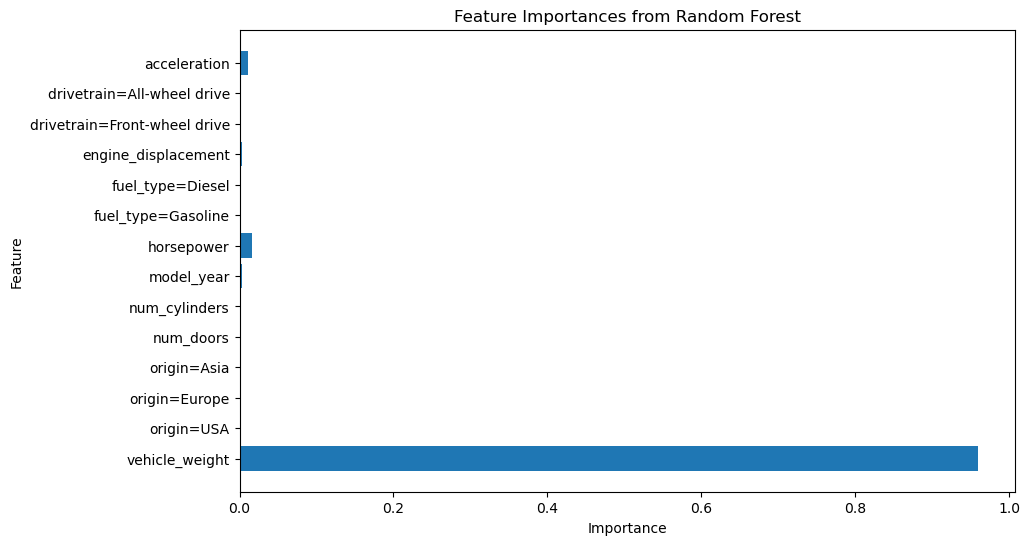

In [53]:
# question 5

rf = RandomForestRegressor(n_estimators=10, max_depth=20, random_state=1, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_val)
print("Validation RMSE:", round((mean_squared_error(y_val, y_pred))**0.5, 3))

importances = rf.feature_importances_
feature_names = dv.get_feature_names_out()
feature_importances = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importances.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feature_importances['feature'], feature_importances['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importances from Random Forest')
plt.gca().invert_yaxis()
plt.show()

In [57]:
!pip install xgboost

In [62]:
# dv.get_feature_names_out().tolist()

In [64]:
# question 6
import xgboost as xgb

features = dv.get_feature_names_out().tolist()
df_train = xgb.DMatrix(X_train, label=y_train, feature_names=features)
df_val = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [66]:
xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}

model1 = xgb.train(xgb_params, df_train, num_boost_round=100)
y_pred = model1.predict(df_val)
rmse = round((mean_squared_error(y_val, y_pred))**0.5, 3)
print("Validation RMSE:", rmse)

Validation RMSE: 0.45


In [67]:
xgb_params = {
    'eta': 0.1, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}

model1 = xgb.train(xgb_params, df_train, num_boost_round=100)
y_pred = model1.predict(df_val)
rmse = round((mean_squared_error(y_val, y_pred))**0.5, 3)
print("Validation RMSE:", rmse)

Validation RMSE: 0.426
